# Part 1: DistilBERT toxicity baseline

Stratified 100k / 20k eval split, binary toxic label, 3-epoch fine-tune, ROC / PR curves, and a threshold sweep.


## Setup

Install dependencies, mount Drive, then run training and evaluation cells in order.


In [10]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [11]:
import subprocess, sys

_pkgs = [
    "transformers", "datasets", "accelerate", "scikit-learn",
    "matplotlib", "seaborn", "torch", "pandas", "numpy",
]
for p in _pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
print("Dependencies OK.")


All packages verified.


In [12]:
import os
import random
import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = "jigsaw-unintended-bias-train.csv"
CHECKPOINT_DIR = "./distilbert_toxic_checkpoint"
TRAIN_SIZE, EVAL_SIZE = 100_000, 20_000
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
EPOCHS = 3
BATCH_SIZE = 32

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{DEVICE=} | torch {torch.__version__}")


Using device: cuda
PyTorch version: 2.10.0+cu128


In [13]:
COLS = ["comment_text", "toxic", "black", "white", "muslim", "jewish", "other_sexual_orientation"]

df = pd.read_csv(DATA_PATH, usecols=COLS, low_memory=False)
df = df.dropna(subset=["comment_text", "toxic"])
df["comment_text"] = df["comment_text"].astype(str)
df["label"] = (df["toxic"] >= 0.5).astype(int)
print(df.shape, df["label"].value_counts(normalize=True).round(3).to_dict())


Loading jigsaw-unintended-bias-train.csv ...
Full dataset shape: (1902194, 7)

Class distribution in full dataset:
label
Non-toxic    0.920034
Toxic        0.079966

Toxic count : 152,111
Non-toxic   : 1,750,080


In [14]:
n = TRAIN_SIZE + EVAL_SIZE
subset, _ = train_test_split(df, train_size=n, stratify=df["label"], random_state=SEED)
df_train, df_eval = train_test_split(
    subset, train_size=TRAIN_SIZE, stratify=subset["label"], random_state=SEED
)
df_train = df_train.reset_index(drop=True)
df_eval = df_eval.reset_index(drop=True)
print(len(df_train), len(df_eval), df_train["label"].mean(), df_eval["label"].mean())


Train set : 100,000 rows
Eval  set : 20,000 rows

Train label distribution:
label
Non-toxic    0.92003
Toxic        0.07997
Name: proportion, dtype: float64

Eval label distribution:
label
Non-toxic    0.92005
Toxic        0.07995
Name: proportion, dtype: float64


In [15]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(
        batch["comment_text"],
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length",
    )

train_hf = Dataset.from_pandas(df_train[["comment_text", "label"]])
eval_hf = Dataset.from_pandas(df_eval[["comment_text", "label"]])
train_tok = train_hf.map(tokenize_fn, batched=True, batch_size=1000, remove_columns=["comment_text"])
eval_tok = eval_hf.map(tokenize_fn, batched=True, batch_size=1000, remove_columns=["comment_text"])
train_tok = train_tok.rename_column("label", "labels")
eval_tok = eval_tok.rename_column("label", "labels")
train_tok.set_format("torch")
eval_tok.set_format("torch")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing training set ...


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Tokenizing evaluation set ...


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]


Train tokenized columns : ['labels', 'input_ids', 'attention_mask']
Eval  tokenized columns : ['labels', 'input_ids', 'attention_mask']
Sample input_ids shape  : torch.Size([128])


In [16]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    pred = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, pred),
        "f1_macro": f1_score(labels, pred, average="macro"),
    }

print(f"params={model.num_parameters():,}")


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 66,955,010
Trainable params: 66,955,010


In [17]:
training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_dir="./logs",
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    compute_metrics=compute_metrics,
)
train_result = trainer.train()
trainer.save_model(CHECKPOINT_DIR)
tokenizer.save_pretrained(CHECKPOINT_DIR)
print("saved", CHECKPOINT_DIR, train_result.metrics)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Using device: cuda
PyTorch version: 2.10.0+cu128
Starting fine-tuning ...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.147041,0.133650,0.947100,0.786961
2,0.120181,0.142342,0.948900,0.813337
3,0.070629,0.176993,0.946450,0.810447


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Checkpoint saved to: ./distilbert_toxic_checkpoint
Training runtime   : 966.9 s
Samples / second   : 310.3


In [18]:
import shutil

DRIVE_DEST = "/content/drive/My Drive/Colab Notebooks/distilbert_toxic_checkpoint"
shutil.copytree(CHECKPOINT_DIR, DRIVE_DEST, dirs_exist_ok=True)
print("copied", len(os.listdir(DRIVE_DEST)), "entries")


✅ Copied to Drive successfully!
Files saved: ['checkpoint-6250', 'checkpoint-3125', 'training_args.bin', 'model.safetensors', 'tokenizer.json', 'config.json', 'tokenizer_config.json', 'checkpoint-9375']


In [19]:
print("predict eval…")
pred_output = trainer.predict(eval_tok)
logits_np = pred_output.predictions
true_labels = pred_output.label_ids
prob_toxic = F.softmax(torch.tensor(logits_np), dim=-1).numpy()[:, 1]
pred_labels_default = (prob_toxic >= 0.5).astype(int)
print(len(true_labels), pred_labels_default.sum(), true_labels.sum())


Running inference on evaluation set ...


Evaluation samples : 20,000
Predicted toxic    : 1,357
Actual toxic       : 1,599


  EVALUATION METRICS  (threshold = 0.50)
  Accuracy        : 0.9489
  F1 (macro)      : 0.8133
  AUC-ROC         : 0.9505


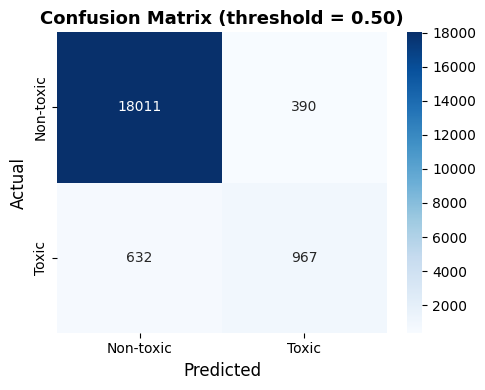


True  Negatives : 18,011   False Positives: 390
False Negatives : 632   True  Positives: 967


In [20]:
acc = accuracy_score(true_labels, pred_labels_default)
f1_mac = f1_score(true_labels, pred_labels_default, average="macro")
auc_roc = roc_auc_score(true_labels, prob_toxic)
cm = confusion_matrix(true_labels, pred_labels_default)
print(f"acc={acc:.4f} f1_macro={f1_mac:.4f} auc={auc_roc:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["clean", "toxic"], yticklabels=["clean", "toxic"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


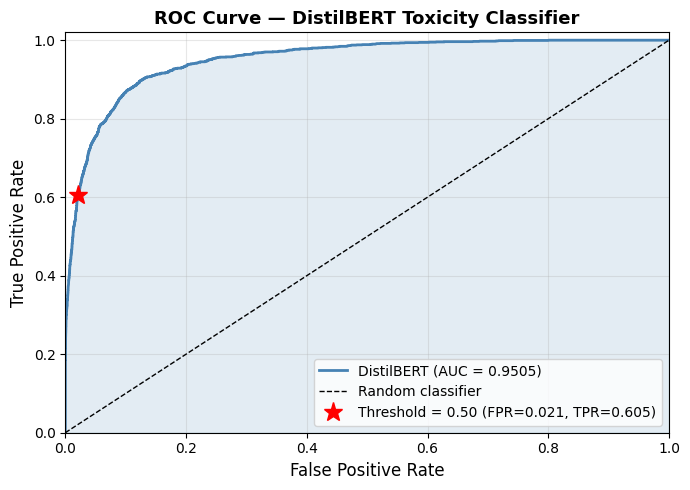

In [21]:
fpr, tpr, roc_thr = roc_curve(true_labels, prob_toxic)
idx = np.argmin(np.abs(roc_thr - 0.5))
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, lw=2, label=f"AUC={auc_roc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.scatter([fpr[idx]], [tpr[idx]], c="r", s=80, zorder=3, label="τ=0.5")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


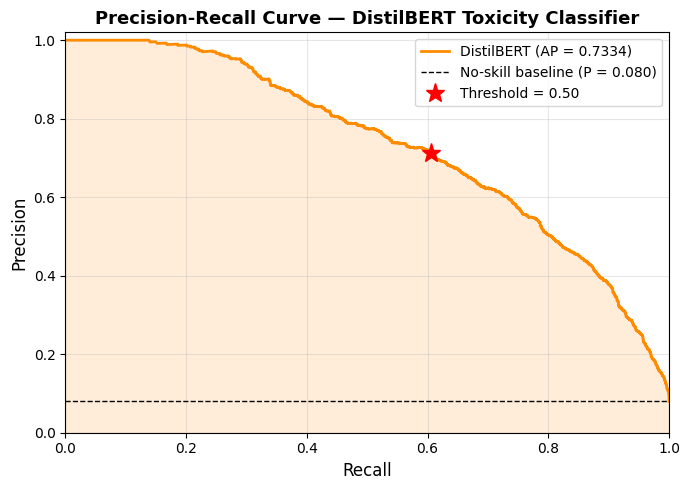

In [22]:
precision, recall, pr_thr = precision_recall_curve(true_labels, prob_toxic)
avg_precision = average_precision_score(true_labels, prob_toxic)
pr_i = np.argmin(np.abs(pr_thr - 0.5))
base = true_labels.mean()
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, lw=2, label=f"AP={avg_precision:.4f}")
ax.axhline(base, color="k", ls="--", lw=1, label=f"prevalence={base:.3f}")
ax.scatter([recall[pr_i]], [precision[pr_i]], c="r", s=80, zorder=3)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Threshold Sweep Results:
 Threshold  Accuracy  F1 (macro)  F1 (toxic)  Precision  Recall (toxic)
       0.3    0.9428      0.8129      0.6571     0.6571          0.6848
       0.4    0.9468      0.8151      0.6590     0.6590          0.6429
       0.5    0.9489      0.8133      0.6543     0.6543          0.6048
       0.6    0.9489      0.8056      0.6386     0.6386          0.5647
       0.7    0.9490      0.7970      0.6214     0.6214          0.5235


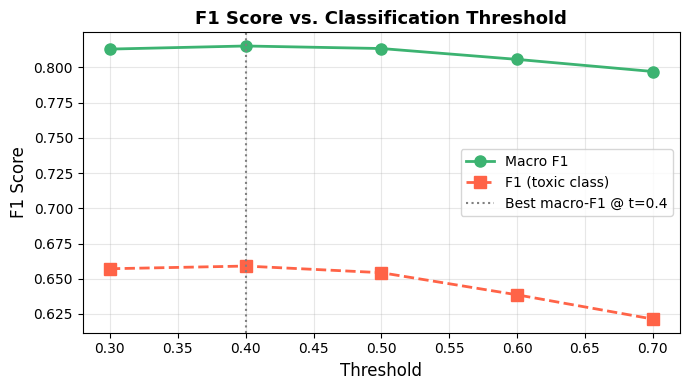


Best macro-F1 achieved at threshold = 0.4


In [23]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for t in thresholds:
    p = (prob_toxic >= t).astype(int)
    rows.append({
        "τ": t,
        "acc": round(accuracy_score(true_labels, p), 4),
        "f1_macro": round(f1_score(true_labels, p, average="macro"), 4),
        "f1_tox": round(f1_score(true_labels, p, pos_label=1), 4),
        "prec": round(precision_score(true_labels, p, pos_label=1, zero_division=0), 4),
        "rec": round(recall_score(true_labels, p, pos_label=1, zero_division=0), 4),
    })
results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

best_t = float(results_df.loc[results_df["f1_macro"].idxmax(), "τ"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(results_df["τ"], results_df["f1_macro"], "o-", label="macro F1")
ax.plot(results_df["τ"], results_df["f1_tox"], "s--", label="toxic F1")
ax.axvline(best_t, color="gray", ls=":", label=f"best macro τ={best_t}")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Threshold justification

Use the sweep table printed above (τ ∈ {0.3,…,0.7}) together with ROC–PR curves. **τ = 0.5** matches the toxic ≥ 0.5 binarization; move lower to favor recall (more flags) or higher to favor precision (fewer false alarms), depending on moderation policy.


In [24]:
CHOSEN_THRESHOLD = best_t
final_preds = (prob_toxic >= CHOSEN_THRESHOLD).astype(int)
print(
    "summary:",
    MODEL_NAME,
    f"epochs={EPOCHS}",
    f"τ={CHOSEN_THRESHOLD}",
    f"acc={accuracy_score(true_labels, final_preds):.4f}",
    f"f1_macro={f1_score(true_labels, final_preds, average='macro'):.4f}",
    f"auc={auc_roc:.4f}",
    f"ap={avg_precision:.4f}",
)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
np.save(os.path.join(CHECKPOINT_DIR, "eval_probs.npy"), prob_toxic)
np.save(os.path.join(CHECKPOINT_DIR, "eval_labels.npy"), true_labels)
df_eval.to_parquet(os.path.join(CHECKPOINT_DIR, "eval_df.parquet"), index=False)


  FINAL EVALUATION SUMMARY
  Model             : distilbert-base-uncased
  Epochs trained    : 3
  Chosen threshold  : 0.4
  Accuracy          : 0.9468
  F1 (macro)        : 0.8151
  AUC-ROC           : 0.9505
  Avg Precision     : 0.7334

Checkpoint directory: ./distilbert_toxic_checkpoint
Files saved         : ['checkpoint-6250', 'checkpoint-3125', 'training_args.bin', 'model.safetensors', 'tokenizer.json', 'config.json', 'tokenizer_config.json', 'checkpoint-9375']

eval_probs.npy, eval_labels.npy, and eval_df.parquet saved for Part 2.


In [25]:
DRIVE_CKPT = "/content/drive/My Drive/Colab Notebooks/distilbert_toxic_checkpoint"
os.makedirs(DRIVE_CKPT, exist_ok=True)
np.save(os.path.join(DRIVE_CKPT, "eval_probs.npy"), prob_toxic)
np.save(os.path.join(DRIVE_CKPT, "eval_labels.npy"), true_labels)
df_eval.to_parquet(os.path.join(DRIVE_CKPT, "eval_df.parquet"), index=False)
print("drive export OK")


✅ Saved eval_probs.npy, eval_labels.npy, eval_df.parquet to Drive
Files now: ['checkpoint-6250', 'checkpoint-3125', 'training_args.bin', 'model.safetensors', 'tokenizer.json', 'config.json', 'tokenizer_config.json', 'checkpoint-9375', 'eval_probs.npy', 'eval_labels.npy', 'eval_df.parquet']
